In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem import PorterStemmer,WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import   StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report,accuracy_score
from sklearn.metrics import  classification_report, confusion_matrix
import pickle

In [36]:
data = pd.read_excel("C:/Users/Aditi/OneDrive/Desktop/Data Analysis/Internship/inshorts/sia.xlsx")

In [37]:
data

,Unnamed: 0,link,headline,category,short_description,authors,date,full_news,news_len,sentiment
0,0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,"['million', 'americans', 'roll', 'sleeves', 'o...",230,neutral
1,1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"['american', 'airlines', 'flyer', 'charged', '...",248,neutral
2,2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,"['funniest', 'tweets', 'cats', 'dogs', 'week',...",133,neutral
3,3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,"['funniest', 'tweets', 'parents', 'week', 'sep...",215,neutral
4,4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,"['woman', 'called', 'cops', 'black', 'bird', '...",233,neutral
...,...,...,...,...,...,...,...,...,...,...
189421,209522,https://www.huffingtonpost.com/entry/rim-ceo-t...,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,Verizon Wireless and AT&T are already promotin...,"Reuters, Reuters",2012-01-28,"['rim', 'ceo', 'thorsten', 'heins', 'significa...",182,neutral
189422,209523,https://www.huffingtonpost.com/entry/maria-sha...,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"Afterward, Azarenka, more effusive with the pr...",NaN,2012-01-28,"['maria', 'sharapova', 'stunned', 'victoria', ...",191,neutral
189423,209524,https://www.huffingtonpost.com/entry/super-bow...,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"Leading up to Super Bowl XLVI, the most talked...",NaN,2012-01-28,"['giants', 'patriots', 'jets', 'colts', 'among...",220,neutral
189424,209525,https://www.huffingtonpost.com/entry/aldon-smi...,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,CORRECTION: An earlier version of this story i...,NaN,2012-01-28,"['aldon', 'smith', 'arrested', 'ers', 'linebac...",173,neutral


In [41]:

positive_data = data[data['sentiment'] == 'positive'].head(3500)
neutral_data = data[data['sentiment'] == 'neutral'].head(3500)
negative_data = data[data['sentiment'] == 'negative'].head(3500)

# Concatenate 
final_data = pd.concat([positive_data, neutral_data, negative_data])

# Shuffle 
final_data = final_data.sample(frac=1).reset_index(drop=True)


In [45]:
#final_data.drop(columns=['category','authors','date','source_website','tags','Pos_headline','Pos','lemm','lemm_headline','stem','stem_headline'],inplace = True)
final_data.drop(columns=['Unnamed: 0','link','news_len'],inplace=True)


In [46]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   headline           10500 non-null  object
 1   category           10500 non-null  object
 2   short_description  10500 non-null  object
 3   full_news          10500 non-null  object
 4   sentiment          10500 non-null  object
dtypes: object(5)
memory usage: 410.3+ KB


In [47]:
y= final_data['sentiment']

final_data.drop(columns=['sentiment'],inplace=True)


<Axes: xlabel='sentiment', ylabel='Count'>

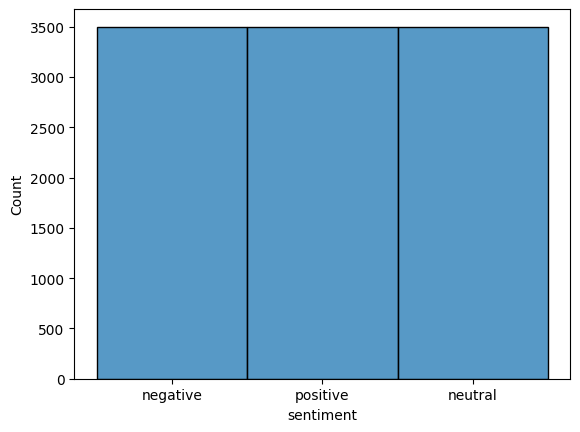

In [48]:
sns.histplot(y,)

In [49]:
X_train,X_test,y_train,y_test = train_test_split(final_data['full_news'],y,test_size=0.2,random_state=0)

In [50]:
vectorizer2 = CountVectorizer()
X_train_cv = vectorizer2.fit_transform(X_train)
X_test_cv = vectorizer2.transform(X_test)

In [51]:
#standardise

std = StandardScaler(with_mean=False)
std.fit_transform(X_train_cv)
std.transform(X_test_cv)

<2100x26198 sparse matrix of type '<class 'numpy.float64'>'
	with 32062 stored elements in Compressed Sparse Row format>

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
multi= SGDClassifier()
multi.fit(X_train_cv, y_train)

y_pred = multi.predict(X_test_cv)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")
print(f"Confusion Matrix:\n{conf_matrix}")

Accuracy: 0.800952380952381
Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.80      0.78       684
     neutral       0.82      0.77      0.79       717
    positive       0.82      0.84      0.83       699

    accuracy                           0.80      2100
   macro avg       0.80      0.80      0.80      2100
weighted avg       0.80      0.80      0.80      2100

Confusion Matrix:
[[545  71  68]
 [103 550  64]
 [ 65  47 587]]
